In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
data=r"E:\vs\module 1\assignment 2 SMS Spam Classification Challenge\spam.csv"
df=pd.read_csv(data)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (5572, 5)


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print(df.head())
print("\nDataset shape:", df.shape)

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Dataset shape: (5572, 2)


In [6]:
df['label'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

print(df.head())
print("\nLabel counts:")
print(df['label'].value_counts())

   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
0    4825
1     747
Name: count, dtype: int64


In [7]:
X_text = df['message']
y = df['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples :", len(X_test_text))

Training samples: 4457
Testing samples : 1115


In [8]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words='english'
)

X_train = vectorizer.fit_transform(X_train_text).toarray()
X_test = vectorizer.transform(X_test_text).toarray()

print("Training feature shape:", X_train.shape)
print("Testing feature shape :", X_test.shape)

Training feature shape: (4457, 2000)
Testing feature shape : (1115, 2000)


In [9]:
class Perceptron:

    def __init__(self, learning_rate=0.01, epochs=10):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.errors = []

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return np.where(linear_output >= 0, 1, 0)

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        self.errors = []

        for epoch in range(self.epochs):

            misclassified = 0

            for xi, target in zip(X, y):

                prediction = self.predict(xi.reshape(1, -1))[0]

                update = self.learning_rate * (target - prediction)

                self.weights += update * xi

                self.bias += update

                if update != 0:
                    misclassified += 1

            self.errors.append(misclassified)

        return self

In [10]:
perceptron = Perceptron(
    learning_rate=0.01,
    epochs=10
)

perceptron.fit(X_train, y_train)

print("Perceptron training completed!")
print("Misclassifications per epoch:")
print(perceptron.errors)

Perceptron training completed!
Misclassifications per epoch:
[281, 94, 60, 57, 33, 40, 30, 20, 20, 24]


In [11]:
y_pred = perceptron.predict(X_test)

accuracy = np.mean(y_pred == y_test)

print(f"Perceptron Test Accuracy: {accuracy * 100:.2f}%")

Perceptron Test Accuracy: 96.59%


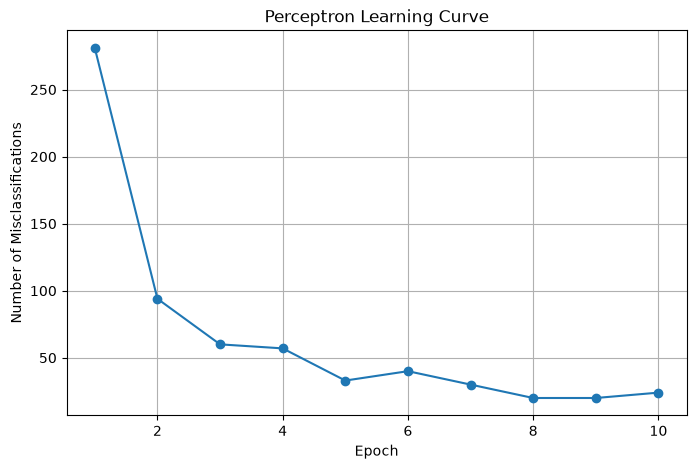

In [12]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(perceptron.errors) + 1),
    perceptron.errors,
    marker='o'
)

plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Perceptron Learning Curve")
plt.grid(True)

plt.show()

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

print("Original shape:", X_train.shape)
print("2D shape:", X_train_2d.shape)

Original shape: (4457, 2000)
2D shape: (4457, 2)


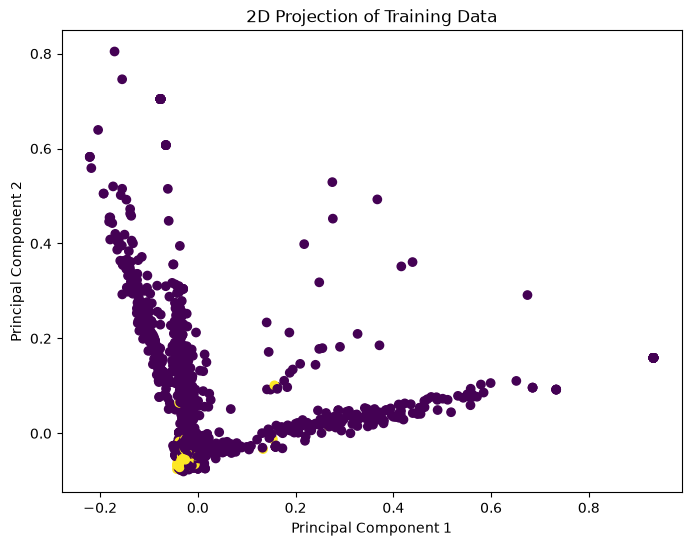

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D Projection of Training Data")
plt.show()

In [15]:
perceptron = Perceptron(learning_rate=0.01, epochs=10)

perceptron.fit(X_train_2d, y_train)

print("Weights:", perceptron.weights)
print("Bias:", perceptron.bias)
print("Errors:", perceptron.errors)

Weights: [-0.09071042 -0.15980036]
Bias: -0.01
Errors: [1005, 998, 862, 790, 778, 772, 764, 764, 766, 764]


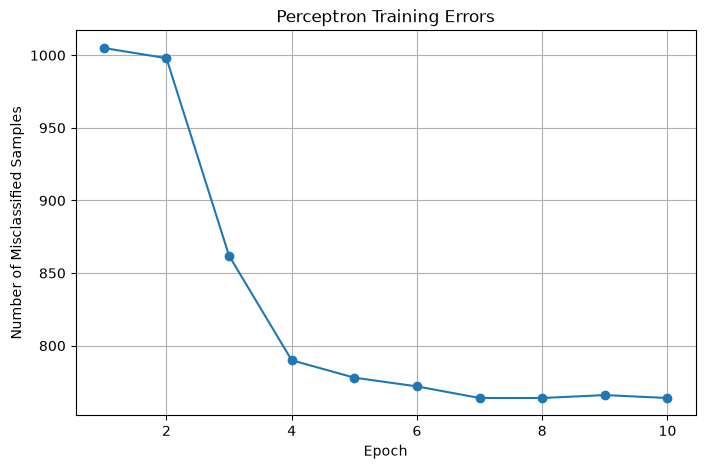

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker='o')

plt.xlabel("Epoch")
plt.ylabel("Number of Misclassified Samples")
plt.title("Perceptron Training Errors")
plt.grid()
plt.show()

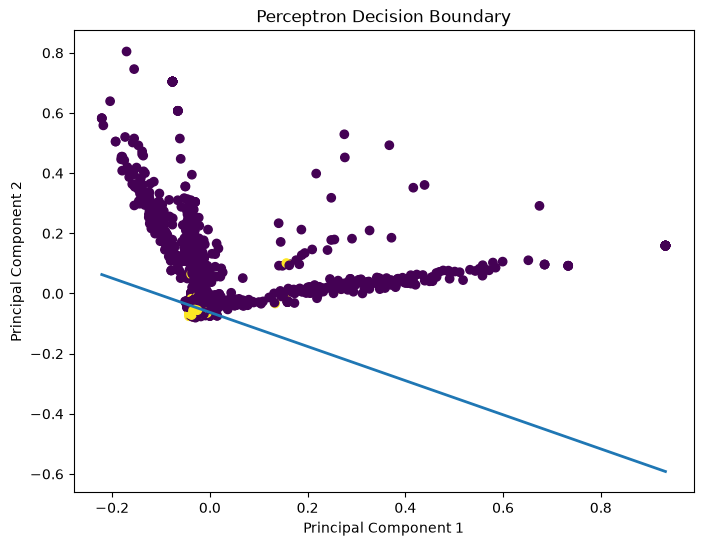

In [17]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train
)

x_min = X_train_2d[:, 0].min()
x_max = X_train_2d[:, 0].max()

x_values = np.array([x_min, x_max])

if perceptron.weights[1] != 0:
    y_values = (
        -(perceptron.weights[0] * x_values + perceptron.bias)
        / perceptron.weights[1]
    )

    plt.plot(x_values, y_values, linewidth=2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Perceptron Decision Boundary")
plt.show()

In [18]:
y_pred = perceptron.predict(X_test_2d)

accuracy = np.mean(y_pred == y_test)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.8672645739910314
Test Accuracy (%): 86.72645739910314


In [19]:
class LogisticRegression:

    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = 0
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):

        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        self.losses = []

        for epoch in range(self.epochs):

            linear_output = np.dot(X, self.weights) + self.bias

            predictions = self.sigmoid(linear_output)

            dw = np.dot(X.T, (predictions - y)) / len(y)

            db = np.sum(predictions - y) / len(y)

            self.weights -= self.learning_rate * dw

            self.bias -= self.learning_rate * db

            loss = -np.mean(
                y * np.log(predictions + 1e-15) +
                (1 - y) * np.log(1 - predictions + 1e-15)
            )

            self.losses.append(loss)

        return self

    def predict_proba(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        probabilities = self.sigmoid(linear_output)

        return probabilities

    def predict(self, X):

        probabilities = self.predict_proba(X)

        return np.where(probabilities >= 0.5, 1, 0)

In [20]:
logistic_model = LogisticRegression(
    learning_rate=0.01,
    epochs=1000
)

logistic_model.fit(X_train_2d, y_train)

print("Weights:", logistic_model.weights)
print("Bias:", logistic_model.bias)

Weights: [-0.02811783 -0.06048117]
Bias: -1.4759540669233537


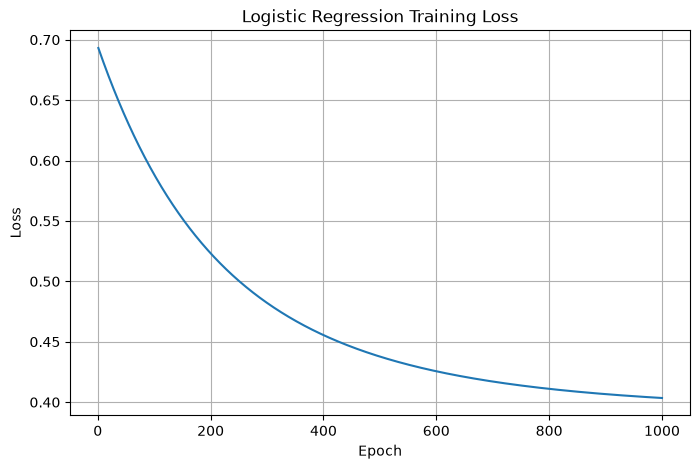

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(logistic_model.losses) + 1),
    logistic_model.losses
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Logistic Regression Training Loss")
plt.grid()

plt.show()

In [22]:
y_pred = logistic_model.predict(X_test_2d)

accuracy = np.mean(y_pred == y_test)

print("Test Accuracy:", accuracy)
print("Test Accuracy (%):", accuracy * 100)

Test Accuracy: 0.8663677130044843
Test Accuracy (%): 86.63677130044843


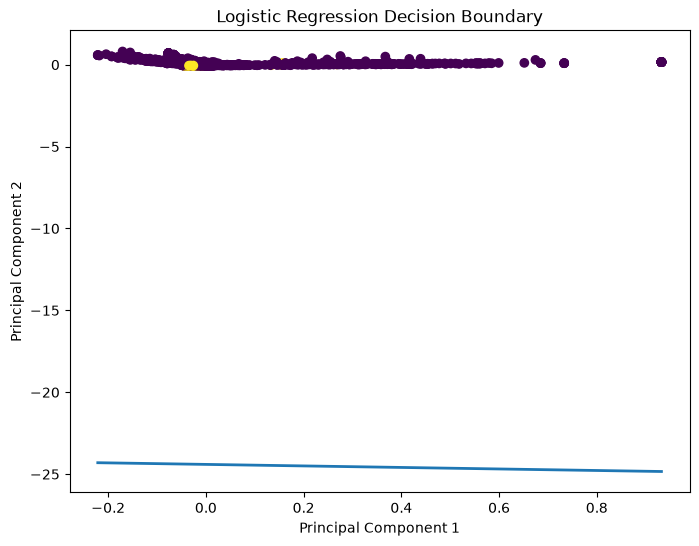

In [23]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_2d[:, 0],
    X_train_2d[:, 1],
    c=y_train
)

x_min = X_train_2d[:, 0].min()
x_max = X_train_2d[:, 0].max()

x_values = np.array([x_min, x_max])

if logistic_model.weights[1] != 0:
    y_values = (
        -(logistic_model.weights[0] * x_values + logistic_model.bias)
        / logistic_model.weights[1]
    )

    plt.plot(x_values, y_values, linewidth=2)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [24]:
import numpy as np

y_true = np.array(y_test)
y_pred = np.array(y_pred)

TP = np.sum((y_true == 1) & (y_pred == 1))
TN = np.sum((y_true == 0) & (y_pred == 0))
FP = np.sum((y_true == 0) & (y_pred == 1))
FN = np.sum((y_true == 1) & (y_pred == 0))

accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0 else 0
)

print("Confusion Matrix Values")
print("-----------------------")
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("\nEvaluation Metrics")
print("------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

Confusion Matrix Values
-----------------------
TP: 0
TN: 966
FP: 0
FN: 149

Evaluation Metrics
------------------
Accuracy : 0.8664
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


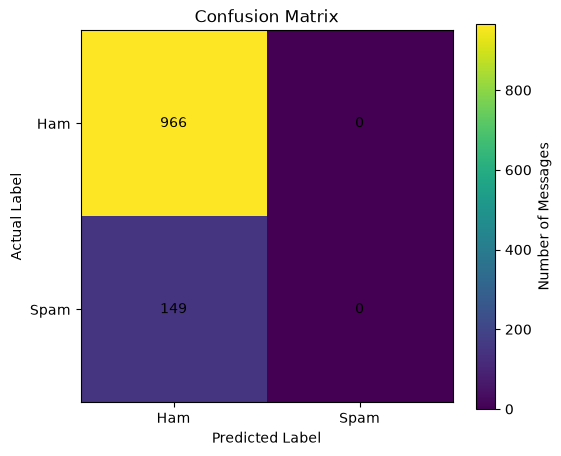

In [25]:
import matplotlib.pyplot as plt

cm = np.array([
    [TN, FP],
    [FN, TP]
])

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar(label="Number of Messages")

plt.show()

In [26]:
# Probability predictions
y_prob = logistic_model.predict_proba(X_test_2d)

# If predict_proba returns 2 columns, take probability of class 1
if y_prob.ndim > 1:
    y_prob = y_prob[:, 1]

print(y_prob[:10])

[0.18459942 0.18635669 0.18640365 0.18661301 0.18442457 0.18662733
 0.1862953  0.18426426 0.18632181 0.18652378]


AUC Score: 0.8560312365389692


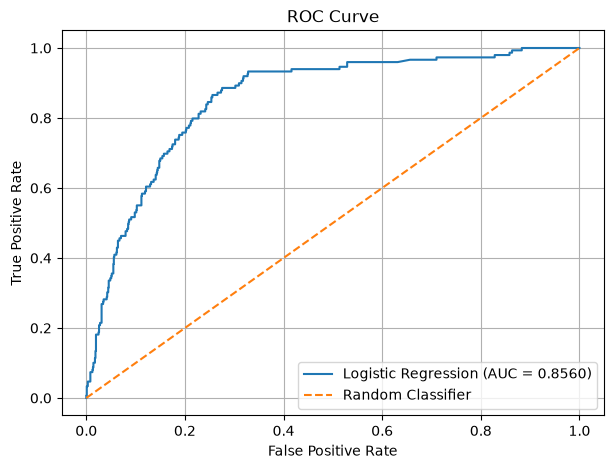

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
thresholds_to_test = [0.3, 0.5, 0.7]

threshold_results = []

for threshold in thresholds_to_test:

    y_pred_threshold = np.where(y_prob >= threshold, 1, 0)

    TP_t = np.sum((y_test == 1) & (y_pred_threshold == 1))
    TN_t = np.sum((y_test == 0) & (y_pred_threshold == 0))
    FP_t = np.sum((y_test == 0) & (y_pred_threshold == 1))
    FN_t = np.sum((y_test == 1) & (y_pred_threshold == 0))

    precision_t = TP_t / (TP_t + FP_t) if (TP_t + FP_t) != 0 else 0

    recall_t = TP_t / (TP_t + FN_t) if (TP_t + FN_t) != 0 else 0

    threshold_results.append([
        threshold,
        precision_t,
        recall_t
    ])

print("Threshold | Precision | Recall")
print("--------------------------------")

for result in threshold_results:
    print(
        f"{result[0]:9.1f} | "
        f"{result[1]:9.4f} | "
        f"{result[2]:.4f}"
    )

Threshold | Precision | Recall
--------------------------------
      0.3 |    0.0000 | 0.0000
      0.5 |    0.0000 | 0.0000
      0.7 |    0.0000 | 0.0000


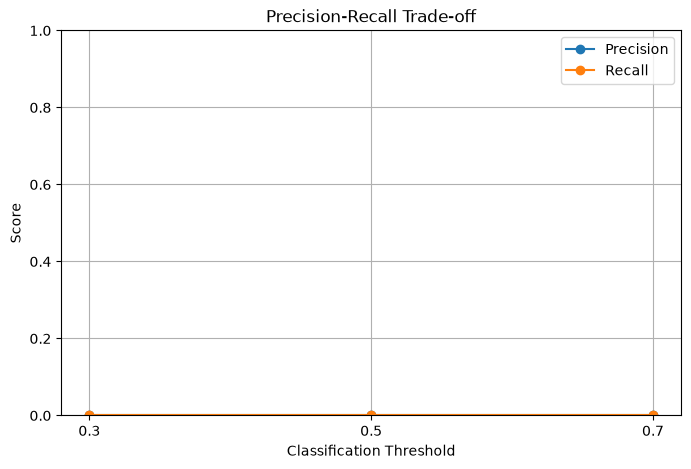

In [35]:

thresholds = [result[0] for result in threshold_results]
precisions = [result[1] for result in threshold_results]
recalls = [result[2] for result in threshold_results]

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    precisions,
    marker='o',
    label='Precision'
)

plt.plot(
    thresholds,
    recalls,
    marker='o',
    label='Recall'
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.legend()
plt.grid(True)

plt.show()

In [30]:

results_df = pd.DataFrame(
    threshold_results,
    columns=["Threshold", "Precision", "Recall"]
)

print(results_df)

best_f1 = -1
best_threshold = None

for threshold in thresholds_to_test:

    y_temp = np.where(y_prob >= threshold, 1, 0)

    TP_temp = np.sum((y_test == 1) & (y_temp == 1))
    FP_temp = np.sum((y_test == 0) & (y_temp == 1))
    FN_temp = np.sum((y_test == 1) & (y_temp == 0))

    p = TP_temp / (TP_temp + FP_temp) if (TP_temp + FP_temp) != 0 else 0
    r = TP_temp / (TP_temp + FN_temp) if (TP_temp + FN_temp) != 0 else 0

    f1 = (
        2 * p * r / (p + r)
        if (p + r) != 0 else 0
    )
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print("\nBest Threshold:", best_threshold)
print("Best F1-score:", round(best_f1, 4))

   Threshold  Precision  Recall
0        0.3          0     0.0
1        0.5          0     0.0
2        0.7          0     0.0

Best Threshold: 0.3
Best F1-score: 0
